# Notebook 5 — Color: RGB vs HSV y segmentación (selección de fruta)

RGB está muy ligado al brillo; HSV separa **matiz (Hue)** de **brillo (Value)** y ayuda a filtrar sombras.
Aplicación industrial en el PDF: **segmentar limones maduros (amarillos) vs inmaduros (verdes)**.

Aquí haremos una versión didáctica con imágenes sintéticas (y opción de usar una foto propia).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## A) Crear una imagen sintética con “frutas” verdes y amarillas + sombra
Generamos círculos de colores sobre fondo y agregamos una sombra (oscurecimiento) para ver la diferencia entre RGB y HSV.


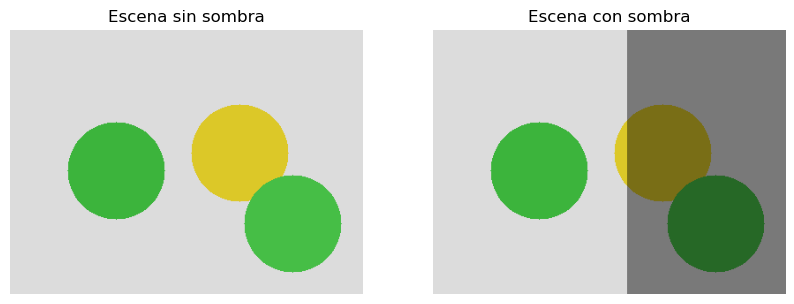

In [8]:
# ============================================================
# GENERACIÓN DE UNA ESCENA RGB SINTÉTICA CON SOMBRA
# (Simulación didáctica de un problema real de visión artificial)
# ============================================================

# ------------------------------------------------------------
# 1) Creamos un lienzo RGB
# ------------------------------------------------------------

# Definimos el tamaño de la imagen
# H = altura (número de filas)
# W = ancho (número de columnas)
H, W = 300, 400

# Creamos una imagen RGB inicializada con el valor 220 en los 3 canales
# np.ones(...) crea una matriz llena de 1s
# * 220 → fondo claro (casi blanco)
# dtype=np.uint8 → valores enteros entre 0 y 255 (formato estándar de imagen)
img = np.ones((H, W, 3), dtype=np.uint8) * 220


# ------------------------------------------------------------
# 2) Función para pintar un círculo de color
# ------------------------------------------------------------

def pintar_circulo(img, cx, cy, r, color_rgb):
    """
    Pinta un círculo sólido de color sobre una imagen RGB.

    Parámetros:
    - img: imagen RGB (H x W x 3)
    - cx, cy: coordenadas del centro del círculo
    - r: radio del círculo (en píxeles)
    - color_rgb: tupla (R, G, B) con valores 0–255
    """

    # np.ogrid crea dos arreglos:
    # yy → coordenadas verticales (filas)
    # xx → coordenadas horizontales (columnas)
    # Esto permite evaluar una ecuación geométrica pixel a pixel
    yy, xx = np.ogrid[:img.shape[0], :img.shape[1]]

    # Máscara booleana del círculo:
    # (x - cx)^2 + (y - cy)^2 <= r^2
    # Representa la ecuación de un círculo en el plano
    mask = (xx - cx)**2 + (yy - cy)**2 <= r**2

    # Asignamos el color RGB solo a los píxeles dentro del círculo
    img[mask] = color_rgb


# ------------------------------------------------------------
# 3) Pintamos “frutas” de distintos colores
# ------------------------------------------------------------

# Pintamos un círculo verde (por ejemplo, fruta inmadura)
pintar_circulo(img, 120, 160, 55, (60, 180, 60))   # verde

# Pintamos un círculo amarillo (fruta madura)
pintar_circulo(img, 260, 140, 55, (220, 200, 40))  # amarillo

# Pintamos otro círculo verde
pintar_circulo(img, 320, 220, 55, (70, 190, 70))   # verde

# En este punto:
# - Tenemos una escena sintética
# - Con colores controlados
# - Sin ruido ni iluminación variable


# ------------------------------------------------------------
# 4) Agregamos una sombra artificial
# ------------------------------------------------------------

# Creamos una matriz de sombra inicializada en 1 (sin cambio)
# dtype=float32 permite multiplicaciones con decimales
sombra = np.ones((H, W), dtype=np.float32)

# Oscurecemos la parte derecha de la imagen
# Multiplicar por 0.55 simula una zona con menos iluminación
sombra[:, 220:] *= 0.55

# Aplicamos la sombra a la imagen:
# - Convertimos img a float para evitar truncamientos
# - Multiplicamos cada canal RGB por el factor de sombra
# - clip(0,255) asegura que los valores sigan siendo válidos
# - Convertimos de nuevo a uint8
img_sombra = (img.astype(np.float32) * sombra[..., None]).clip(0, 255).astype(np.uint8)


# ------------------------------------------------------------
# 5) Visualización de la escena
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

# Imagen original (sin sombra)
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Escena sin sombra')
plt.axis('off')

# Imagen con sombra aplicada
plt.subplot(1, 2, 2)
plt.imshow(img_sombra)
plt.title('Escena con sombra')
plt.axis('off')

plt.show()



## B) Convertir RGB → HSV (sin usar OpenCV)
Para que el ejemplo no dependa de OpenCV, implementamos una conversión simple.
En un proyecto real, usarías `cv2.cvtColor`.


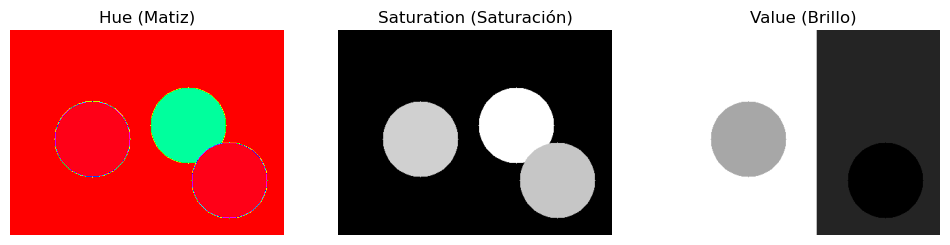

In [6]:
# ============================================================
# CONVERSIÓN DE RGB A HSV (IMPLEMENTACIÓN DIDÁCTICA)
# ============================================================

# Definimos una función que convierte una imagen RGB a HSV
# Entrada:
#   img_rgb → imagen en formato H x W x 3 con valores 0–255
# Salida:
#   h → Matiz (Hue) en grados [0, 360)
#   s → Saturación (Saturation) en rango [0, 1]
#   v → Brillo (Value) en rango [0, 1]
def rgb_a_hsv(img_rgb):

    # Convertimos la imagen a tipo float para poder dividir
    # y normalizamos los valores a [0,1]
    rgb = img_rgb.astype(np.float32) / 255.0

    # Separamos los canales Rojo, Verde y Azul
    # Cada uno es una matriz H x W
    r = rgb[..., 0]   # Canal rojo
    g = rgb[..., 1]   # Canal verde
    b = rgb[..., 2]   # Canal azul

    # Para cada píxel calculamos el valor máximo entre R, G y B
    # Esto representa el canal dominante del color
    cmax = np.maximum(np.maximum(r, g), b)

    # Para cada píxel calculamos el valor mínimo entre R, G y B
    cmin = np.minimum(np.minimum(r, g), b)

    # Delta mide la diferencia entre el canal dominante y el menor
    # Si delta = 0 → el píxel es gris (sin color)
    delta = cmax - cmin

    # ========================================================
    # CÁLCULO DEL HUE (H)
    # ========================================================

    # Inicializamos el Hue con ceros
    # Hue solo se define cuando hay color (delta > 0)
    h = np.zeros_like(cmax)

    # Creamos una máscara para evitar divisiones entre cero
    # Solo calculamos Hue donde realmente hay color
    mask = delta > 1e-9

    # --- Caso 1: el canal dominante es el rojo ---
    idx = (cmax == r) & mask

    # Fórmula del Hue cuando R es el máximo:
    # H = 60 * (G - B) / delta
    # +360 y %360 garantizan que el ángulo quede en [0,360)
    h[idx] = (60 * ((g[idx] - b[idx]) / delta[idx]) + 360) % 360

    # --- Caso 2: el canal dominante es el verde ---
    idx = (cmax == g) & mask

    # Fórmula del Hue cuando G es el máximo:
    # H = 60 * (B - R) / delta + 120
    h[idx] = (60 * ((b[idx] - r[idx]) / delta[idx]) + 120) % 360

    # --- Caso 3: el canal dominante es el azul ---
    idx = (cmax == b) & mask

    # Fórmula del Hue cuando B es el máximo:
    # H = 60 * (R - G) / delta + 240
    h[idx] = (60 * ((r[idx] - g[idx]) / delta[idx]) + 240) % 360

    # ========================================================
    # CÁLCULO DE LA SATURACIÓN (S)
    # ========================================================

    # Inicializamos la saturación con ceros
    s = np.zeros_like(cmax)

    # Saturación se define como:
    # S = delta / cmax
    # Solo se calcula donde cmax > 0
    s[cmax > 1e-9] = delta[cmax > 1e-9] / cmax[cmax > 1e-9]

    # ========================================================
    # CÁLCULO DEL VALUE (V)
    # ========================================================

    # El Value representa el brillo
    # En HSV es simplemente el valor máximo entre R, G y B
    v = cmax

    # Regresamos los tres canales HSV
    return h, s, v


# ============================================================
# APLICAMOS LA FUNCIÓN A UNA IMAGEN CON SOMBRA
# ============================================================

h, s, v = rgb_a_hsv(img_sombra)


# ============================================================
# VISUALIZACIÓN DE LOS CANALES HSV
# ============================================================

plt.figure(figsize=(12, 4))

# ------------------ Hue ------------------
plt.subplot(1, 3, 1)

# Hue está en grados [0,360], lo normalizamos a [0,1]
# para poder visualizarlo correctamente
plt.imshow(h / 360.0, cmap='hsv')
plt.title('Hue (Matiz)')
plt.axis('off')

# ------------------ Saturation ------------------
plt.subplot(1, 3, 2)

# Saturación indica qué tan puro es el color
# Blanco = color intenso, negro = gris
plt.imshow(s, cmap='gray')
plt.title('Saturation (Saturación)')
plt.axis('off')

# ------------------ Value ------------------
plt.subplot(1, 3, 3)

# Value representa el brillo
# Blanco = muy brillante, negro = oscuro
plt.imshow(v, cmap='gray')
plt.title('Value (Brillo)')
plt.axis('off')

plt.show()



## C) Segmentación: detectar “amarillos” usando Hue
Idea: el amarillo suele estar cerca de H ≈ 45–70 grados (aprox).
Creamos una máscara: `H entre [35, 85]` y además `S` suficiente.


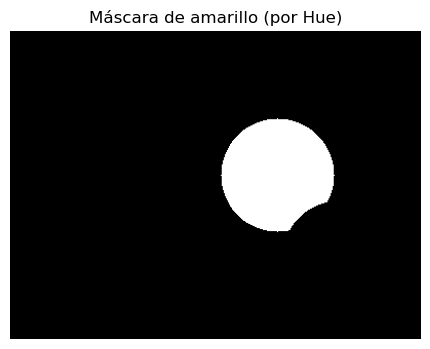

In [4]:
# 7) Umbrales simples
Hmin, Hmax = 35, 85
Smin = 0.25

mask_amarillo = (h >= Hmin) & (h <= Hmax) & (s >= Smin)

# 8) Visualizamos la máscara
plt.figure(figsize=(6,4))
plt.imshow(mask_amarillo, cmap='gray')
plt.title('Máscara de amarillo (por Hue)')
plt.axis('off')
plt.show()


## D) Comparación: segmentación ingenua en RGB (falla con sombra)
Si en RGB intentas decir “amarillo = R alto y G alto”, la sombra baja R y G y puedes perder detección.


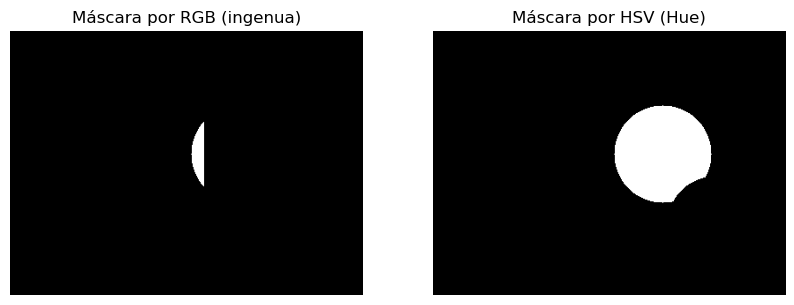

In [7]:

# ============================================================
# SEGMENTACIÓN INGenua POR COLOR USANDO RGB
# (Comparación con segmentación en HSV)
# ============================================================

# Convertimos la imagen a enteros con signo (int16)
# Esto evita posibles desbordamientos si luego se hacen restas
rgb = img_sombra.astype(np.int16)

# Separamos los tres canales de color
# R → intensidad de rojo
# G → intensidad de verde
# B → intensidad de azul
R = rgb[..., 0]
G = rgb[..., 1]
B = rgb[..., 2]

# ------------------------------------------------------------
# DEFINICIÓN DE UMBRALES EN RGB (MÉTODO INGENUO)
# ------------------------------------------------------------
# La idea intuitiva aquí es:
# "El amarillo tiene mucho rojo y mucho verde,
#  y poco azul"

# Condiciones:
# R > 160 → componente roja alta
# G > 150 → componente verde alta
# B < 120 → componente azul baja
mask_rgb = (R > 160) & (G > 150) & (B < 120)

# mask_rgb es una imagen binaria:
# True  → píxeles clasificados como "amarillo"
# False → resto de la imagen


# ============================================================
# VISUALIZACIÓN DE RESULTADOS
# ============================================================

plt.figure(figsize=(10, 4))

# ------------------ Máscara RGB ------------------
plt.subplot(1, 2, 1)

# Mostramos la máscara generada con RGB
# Blanco = detectado como amarillo
# Negro = no detectado
plt.imshow(mask_rgb, cmap='gray')
plt.title('Máscara por RGB (ingenua)')
plt.axis('off')

# ------------------ Máscara HSV ------------------
plt.subplot(1, 2, 2)

# Mostramos la máscara obtenida usando HSV
# Esta máscara fue calculada previamente usando H y S
plt.imshow(mask_amarillo, cmap='gray')
plt.title('Máscara por HSV (Hue)')
plt.axis('off')

plt.show()


### Conclusión
En HSV, el matiz se mantiene más estable ante cambios de iluminación (sombra), por eso es común en inspección de frutas y objetos por color.


## Rangos de color en el espacio HSV utilizados en Visión Artificial

En visión artificial, el espacio de color **HSV (Hue, Saturation, Value)** es ampliamente utilizado porque permite separar el **tipo de color** de la **intensidad de iluminación**, haciendo los sistemas más robustos ante sombras y cambios de luz.

### Componente Hue (H)

El componente **H (Hue)** representa el matiz del color y se mide en grados dentro del intervalo **[0°, 360°)**, formando un círculo cromático.

En aplicaciones reales, los colores no se representan con un valor único de H, sino con **rangos**, debido a variaciones de iluminación, material y sensor.

### Rangos típicos de colores en HSV

| Color        | Rango de H (grados) | Comentarios |
|-------------|--------------------|-------------|
| **Rojo**    | [0–10] y [350–360] | El rojo está en los extremos del círculo HSV |
| **Naranja** | [10–35]            | Transición entre rojo y amarillo |
| **Amarillo**| [35–85]            | Frutas, señales, objetos industriales |
| **Verde**   | [85–160]           | Vegetación, objetos inmaduros |
| **Cian**    | [160–200]          | Agua, superficies técnicas |
| **Azul**    | [200–260]          | Cables, piezas industriales |
| **Magenta** | [260–320]          | Marcadores, etiquetas |
| **Rosa**    | [320–350]          | Tonos suaves de rojo |

> Estos rangos pueden ajustarse según la cámara, el entorno y el objeto de interés.

---

### Componente Saturation (S)

La **Saturación (S)** indica qué tan puro o intenso es el color:

- `S = 0` → gris (sin información de color).
- `S ≈ 1` → color puro e intenso.

En la práctica:
- Sombras, reflejos y brillo excesivo reducen el valor de `S`.
- Por ello se define un umbral mínimo de saturación.

```python
Smin = 0.25
